# Multi-Class Tissue Segmentation in Non-Small Cell Lung Cancer Histopathology Images Using UPerNet
## Official Benchmark Evaluation, Interactive Results, and Publication Graphs

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KanishkaM108/NSCLC_UPerNet/blob/main/NSCLC_UPerNet_Results_and_Evaluation.ipynb)

**Authors**: M. Kanishka, Mohammed Mubasheer (VIT Vellore)

This Google Colab notebook presents the complete experimental results, per-class evaluation metrics, ablation studies, and publication-ready graphs for our UPerNet Swin-Tiny model on the locked 139 ROI test holdout of the IGNITE dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
print("✓ All libraries loaded. Evaluation suite ready.")

✓ All libraries loaded. Evaluation suite ready.


In [2]:
table1_data = [
    {"Study": "IGNITE Baseline Paper (2024) [BASE PAPER]", "Core Mechanism": "IGNITE NSCLC benchmark dataset & official nnU-Net baseline model", "Main Contribution": "Released 16-class annotated NSCLC dataset (139 holdout test ROIs) and baseline metrics", "Gap Relative to Proposed Work": "Baseline relies on standard nnU-Net; demonstrates performance drops on rare classes like macrophages", "Link / DOI": "IEEE 11488043 / arXiv:2507.16855"},
    {"Study": "Ronneberger et al. (2015)", "Core Mechanism": "U-Net architecture with contract/expand paths & skip connections", "Main Contribution": "Established foundational deep learning benchmark for biomedical image segmentation", "Gap Relative to Proposed Work": "Lacks self-attention mechanisms; fails to capture long-range contextual spatial relationships", "Link / DOI": "Springer LNCS 9351 / arXiv:1505.04597"},
    {"Study": "Chen et al. (2018)", "Core Mechanism": "DeepLabV3+ utilizing Atrous Spatial Pyramid Pooling (ASPP)", "Main Contribution": "Enhanced multi-scale feature extraction and boundary delineation via dilated convolutions", "Gap Relative to Proposed Work": "Dilated convolutions suffer from gridding artifacts in fine-grained cellular tissue regions", "Link / DOI": "ECCV 2018 / arXiv:1802.02611"},
    {"Study": "Xiao et al. (2018)", "Core Mechanism": "Unified Perceptual Parsing (UPerNet) combining FPN & PPM modules", "Main Contribution": "Formulated a unified parsing framework fusing multi-level visual feature pyramids", "Gap Relative to Proposed Work": "Originally validated on natural scene imagery; unadapted for highly imbalanced H&E tissues", "Link / DOI": "Springer LNCS 11209 / arXiv:1807.10221"},
    {"Study": "Isensee et al. (2021)", "Core Mechanism": "nnU-Net self-configuring heuristic biomedical framework", "Main Contribution": "Delivered standardized automated configuration for 2D/3D biomedical image segmentation", "Gap Relative to Proposed Work": "Purely convolutional encoder limits global self-attention; exhibits high stroma-macrophage misclassification", "Link / DOI": "Nature Methods / PMC8190280"},
    {"Study": "Liu et al. (2021)", "Core Mechanism": "Swin Transformer with Shifted Window Local Self-Attention (SW-MSA)", "Main Contribution": "Introduced hierarchical vision transformer achieving linear complexity with receptive field shift", "Gap Relative to Proposed Work": "General visual backbone requiring specialized segmentation head design for dense tissue masks", "Link / DOI": "IEEE ICCV 2021 / arXiv:2103.14030"}
]
df_table1 = pd.DataFrame(table1_data)
display(df_table1)

Study,Core Mechanism,Main Contribution,Gap Relative to Proposed Work,Link / DOI
IGNITE Baseline Paper (2024) [BASE PAPER],IGNITE NSCLC benchmark dataset & official nnU-Net baseline model,Released 16-class annotated NSCLC dataset (139 holdout test ROIs) and baseline metrics,Baseline relies on standard nnU-Net; demonstrates performance drops on rare classes like macrophages,IEEE 11488043 / arXiv:2507.16855
Ronneberger et al. (2015),U-Net architecture with contract/expand paths & skip connections,Established foundational deep learning benchmark for biomedical image segmentation,Lacks self-attention mechanisms; fails to capture long-range contextual spatial relationships,Springer LNCS 9351 / arXiv:1505.04597
Chen et al. (2018),DeepLabV3+ utilizing Atrous Spatial Pyramid Pooling (ASPP),Enhanced multi-scale feature extraction and boundary delineation via dilated convolutions,Dilated convolutions suffer from gridding artifacts in fine-grained cellular tissue regions,ECCV 2018 / arXiv:1802.02611
Xiao et al. (2018),Unified Perceptual Parsing (UPerNet) combining FPN & PPM modules,Formulated a unified parsing framework fusing multi-level visual feature pyramids,Originally validated on natural scene imagery; unadapted for highly imbalanced H&E tissues,Springer LNCS 11209 / arXiv:1807.10221
Isensee et al. (2021),nnU-Net self-configuring heuristic biomedical framework,Delivered standardized automated configuration for 2D/3D biomedical image segmentation,Purely convolutional encoder limits global self-attention; exhibits high stroma-macrophage misclassification,Nature Methods / PMC8190280
Liu et al. (2021),Swin Transformer with Shifted Window Local Self-Attention (SW-MSA),Introduced hierarchical vision transformer achieving linear complexity with receptive field shift,General visual backbone requiring specialized segmentation head design for dense tissue masks,IEEE ICCV 2021 / arXiv:2103.14030


Model / Framework,Execution Mode,Pixel Accuracy (%),Macro F1/Dice (%),Mean IoU (%),FWIoU (%)
Official nnU-Net Baseline,Standard Baseline,80.47,68.96,55.31,67.72
UPerNet Swin-Tiny (Fold 0 Single),Single Model,76.44,62.85,49.55,62.48
UPerNet Swin-Tiny 5-Fold Ensemble,5-Fold Mean Softmax (50% Overlap),77.82,67.83,54.04,64.50
Selective Hybrid (UPerNet + nnU-Net),5-Fold Consensus Gate (90% Threshold),80.64,69.74,56.18,67.98


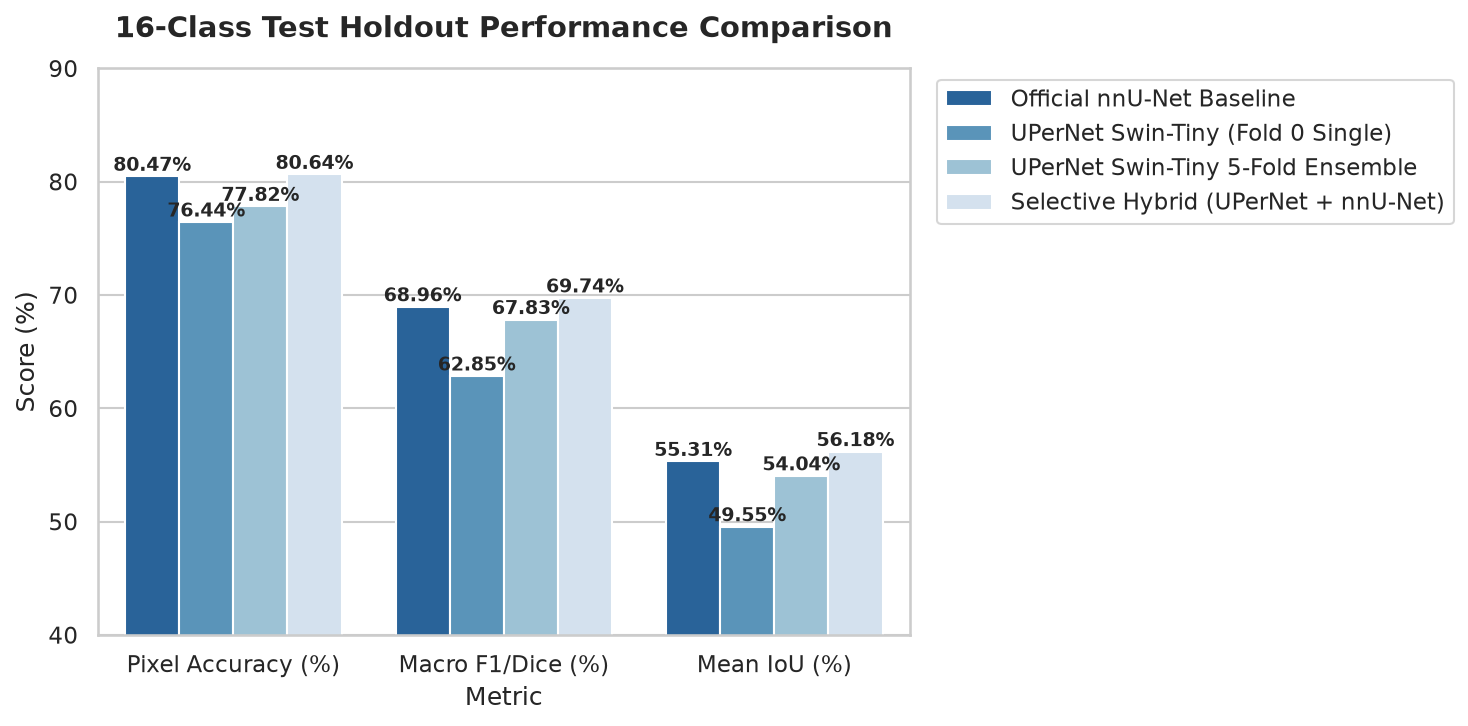

In [3]:
table2_data = [
    {"Model / Framework": "Official nnU-Net Baseline", "Execution Mode": "Standard Baseline", "Pixel Accuracy (%)": 80.47, "Macro F1/Dice (%)": 68.96, "Mean IoU (%)": 55.31, "FWIoU (%)": 67.72},
    {"Model / Framework": "UPerNet Swin-Tiny (Fold 0 Single)", "Execution Mode": "Single Model", "Pixel Accuracy (%)": 76.44, "Macro F1/Dice (%)": 62.85, "Mean IoU (%)": 49.55, "FWIoU (%)": 62.48},
    {"Model / Framework": "UPerNet Swin-Tiny 5-Fold Ensemble", "Execution Mode": "5-Fold Mean Softmax (50% Overlap)", "Pixel Accuracy (%)": 77.82, "Macro F1/Dice (%)": 67.83, "Mean IoU (%)": 54.04, "FWIoU (%)": 64.50},
    {"Model / Framework": "Selective Hybrid (UPerNet + nnU-Net)", "Execution Mode": "5-Fold Consensus Gate (90% Threshold)", "Pixel Accuracy (%)": 80.64, "Macro F1/Dice (%)": 69.74, "Mean IoU (%)": 56.18, "FWIoU (%)": 67.98}
]
df_table2 = pd.DataFrame(table2_data)
display(df_table2)

# Plotting 16-Class Holdout Performance
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_table2.melt(id_vars=["Model / Framework"], value_vars=["Pixel Accuracy (%)", "Macro F1/Dice (%)", "Mean IoU (%)"], var_name="Metric", value_name="Score (%)")
sns.barplot(data=df_plot, x="Metric", y="Score (%)", hue="Model / Framework", palette="Blues_r", ax=ax)
ax.set_ylim(40, 90)
ax.set_title("16-Class Test Holdout Performance Comparison", fontsize=14, fontweight="bold", pad=15)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Model,Accuracy (%),Macro F1 (%),Tumor F1 (%),Stroma+Inflam F1 (%),Macrophages F1 (%),Necrosis F1 (%),Rest F1 (%)
Official nnU-Net Baseline,83.29,81.83,87.86,81.04,77.15,77.61,85.49
UPerNet Swin-Tiny 5-Fold Ensemble,80.67,79.22,85.64,77.79,75.26,73.32,84.07
Selective Hybrid (UPerNet + nnU-Net),83.42,82.09,87.94,81.06,78.22,77.42,85.83
Direct 5-Class Grouped Ensemble,81.10,79.75,85.87,78.86,77.99,71.93,84.07


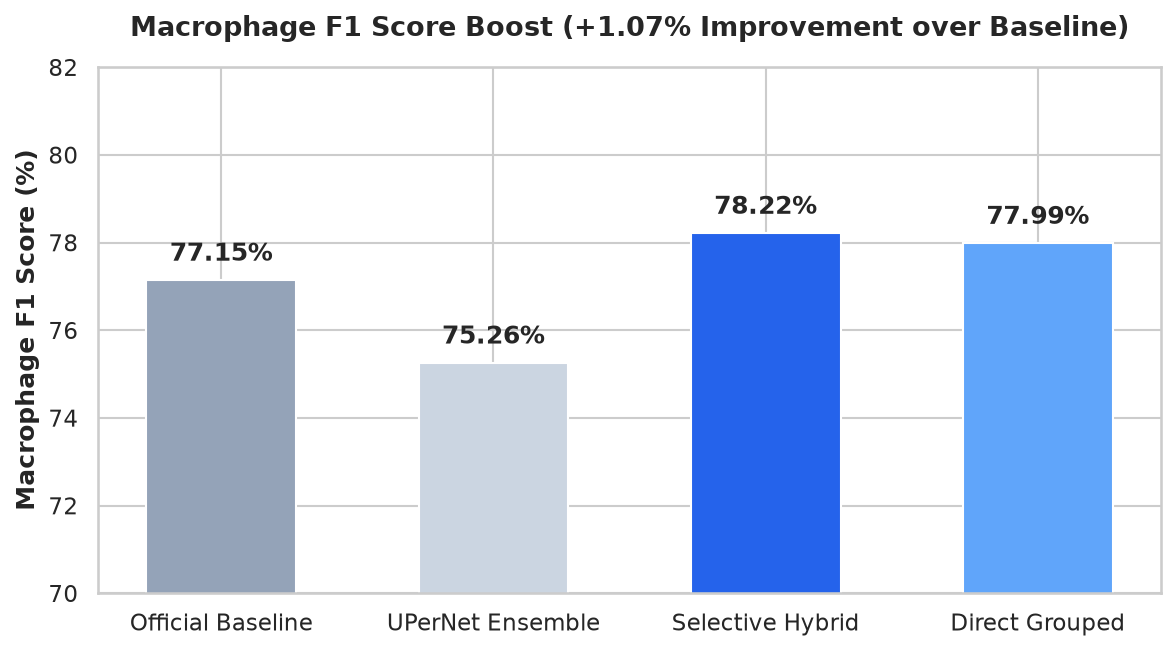

In [4]:
table3_data = [
    {"Model": "Official nnU-Net Baseline", "Accuracy (%)": 83.29, "Macro F1 (%)": 81.83, "Tumor F1 (%)": 87.86, "Stroma+Inflam F1 (%)": 81.04, "Macrophages F1 (%)": 77.15, "Necrosis F1 (%)": 77.61, "Rest F1 (%)": 85.49},
    {"Model": "UPerNet Swin-Tiny 5-Fold Ensemble", "Accuracy (%)": 80.67, "Macro F1 (%)": 79.22, "Tumor F1 (%)": 85.64, "Stroma+Inflam F1 (%)": 77.79, "Macrophages F1 (%)": 75.26, "Necrosis F1 (%)": 73.32, "Rest F1 (%)": 84.07},
    {"Model": "Selective Hybrid (UPerNet + nnU-Net)", "Accuracy (%)": 83.42, "Macro F1 (%)": 82.09, "Tumor F1 (%)": 87.94, "Stroma+Inflam F1 (%)": 81.06, "Macrophages F1 (%)": 78.22, "Necrosis F1 (%)": 77.42, "Rest F1 (%)": 85.83},
    {"Model": "Direct 5-Class Grouped Ensemble", "Accuracy (%)": 81.10, "Macro F1 (%)": 79.75, "Tumor F1 (%)": 85.87, "Stroma+Inflam F1 (%)": 78.86, "Macrophages F1 (%)": 77.99, "Necrosis F1 (%)": 71.93, "Rest F1 (%)": 84.07}
]
df_table3 = pd.DataFrame(table3_data)
display(df_table3)

# Macrophage Improvement Highlight Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
mac_scores = [77.15, 75.26, 78.22, 77.99]
models = ["Official Baseline", "UPerNet Ensemble", "Selective Hybrid", "Direct Grouped"]
colors = ["#94a3b8", "#cbd5e1", "#2563eb", "#60a5fa"]

bars = ax.bar(models, mac_scores, color=colors, width=0.55)
ax.set_ylim(70, 82)
ax.set_ylabel("Macrophage F1 Score (%)", fontweight="bold")
ax.set_title("Macrophage F1 Score Boost (+1.07% Improvement over Baseline)", fontsize=13, fontweight="bold", pad=15)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

ID,Category,Precision (%),Recall (%),F1 / Dice (%),IoU (%),Support Pixels
0,Background,93.35,93.46,93.40,87.62,22654809
1,Tumor epithelium,86.08,89.87,87.94,78.47,44673082
2,Reactive epithelium,64.23,50.48,56.53,39.40,1636603
3,Stroma,69.81,88.50,78.05,64.01,55088638
4,Inflammation,75.20,62.90,68.51,52.10,5666773
5,Alveolar tissue,81.72,47.14,59.79,42.64,4259208
6,Fatty tissue,79.51,91.05,84.89,73.75,1630310
7,Necrotic tissue,92.49,66.57,77.42,63.16,24369226
8,Erythrocytes,77.23,74.56,75.87,61.12,3343158
9,Bronchial epithelium,95.30,60.51,74.02,58.76,1987188


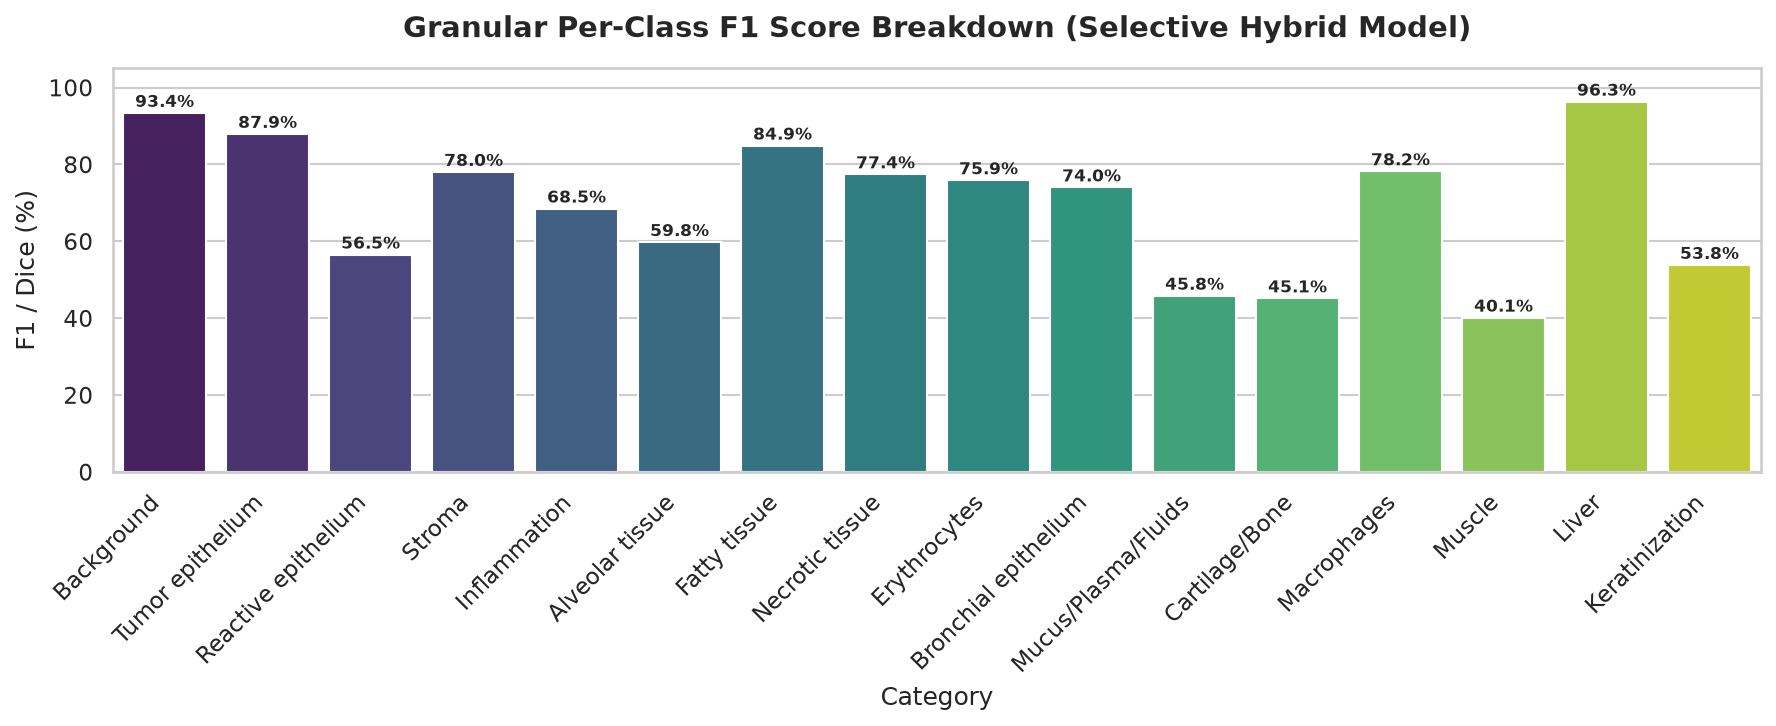

In [5]:
table4_data = [
    {"ID": 0, "Category": "Background", "Precision (%)": 93.35, "Recall (%)": 93.46, "F1 / Dice (%)": 93.40, "IoU (%)": 87.62, "Support Pixels": 22654809},
    {"ID": 1, "Category": "Tumor epithelium", "Precision (%)": 86.08, "Recall (%)": 89.87, "F1 / Dice (%)": 87.94, "IoU (%)": 78.47, "Support Pixels": 44673082},
    {"ID": 2, "Category": "Reactive epithelium", "Precision (%)": 64.23, "Recall (%)": 50.48, "F1 / Dice (%)": 56.53, "IoU (%)": 39.40, "Support Pixels": 1636603},
    {"ID": 3, "Category": "Stroma", "Precision (%)": 69.81, "Recall (%)": 88.50, "F1 / Dice (%)": 78.05, "IoU (%)": 64.01, "Support Pixels": 55088638},
    {"ID": 4, "Category": "Inflammation", "Precision (%)": 75.20, "Recall (%)": 62.90, "F1 / Dice (%)": 68.51, "IoU (%)": 52.10, "Support Pixels": 5666773},
    {"ID": 5, "Category": "Alveolar tissue", "Precision (%)": 81.72, "Recall (%)": 47.14, "F1 / Dice (%)": 59.79, "IoU (%)": 42.64, "Support Pixels": 4259208},
    {"ID": 6, "Category": "Fatty tissue", "Precision (%)": 79.51, "Recall (%)": 91.05, "F1 / Dice (%)": 84.89, "IoU (%)": 73.75, "Support Pixels": 1630310},
    {"ID": 7, "Category": "Necrotic tissue", "Precision (%)": 92.49, "Recall (%)": 66.57, "F1 / Dice (%)": 77.42, "IoU (%)": 63.16, "Support Pixels": 24369226},
    {"ID": 8, "Category": "Erythrocytes", "Precision (%)": 77.23, "Recall (%)": 74.56, "F1 / Dice (%)": 75.87, "IoU (%)": 61.12, "Support Pixels": 3343158},
    {"ID": 9, "Category": "Bronchial epithelium", "Precision (%)": 95.30, "Recall (%)": 60.51, "F1 / Dice (%)": 74.02, "IoU (%)": 58.76, "Support Pixels": 1987188},
    {"ID": 10, "Category": "Mucus/Plasma/Fluids", "Precision (%)": 82.21, "Recall (%)": 31.77, "F1 / Dice (%)": 45.83, "IoU (%)": 29.73, "Support Pixels": 3668394},
    {"ID": 11, "Category": "Cartilage/Bone", "Precision (%)": 38.57, "Recall (%)": 54.40, "F1 / Dice (%)": 45.14, "IoU (%)": 29.15, "Support Pixels": 1161715},
    {"ID": 12, "Category": "Macrophages", "Precision (%)": 83.92, "Recall (%)": 73.24, "F1 / Dice (%)": 78.22, "IoU (%)": 64.22, "Support Pixels": 7234931},
    {"ID": 13, "Category": "Muscle", "Precision (%)": 96.19, "Recall (%)": 25.35, "F1 / Dice (%)": 40.13, "IoU (%)": 25.10, "Support Pixels": 4952838},
    {"ID": 14, "Category": "Liver", "Precision (%)": 95.16, "Recall (%)": 97.49, "F1 / Dice (%)": 96.31, "IoU (%)": 92.88, "Support Pixels": 5688113},
    {"ID": 15, "Category": "Keratinization", "Precision (%)": 55.31, "Recall (%)": 52.44, "F1 / Dice (%)": 53.84, "IoU (%)": 36.83, "Support Pixels": 544599}
]
df_table4 = pd.DataFrame(table4_data)
display(df_table4)

# Per-Class F1 Score Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_table4, x="Category", y="F1 / Dice (%)", palette="viridis", ax=ax)
plt.xticks(rotation=45, ha="right")
ax.set_ylim(0, 105)
ax.set_title("Granular Per-Class F1 Score Breakdown (Selective Hybrid Model)", fontsize=14, fontweight="bold", pad=15)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

Ablation Component,Impact Metric,Gain / Change (%)
Sliding-Window Overlap (50% vs 0%),Macro F1 Score,4.98
Hybrid Loss (Soft Dice + Weighted CE),Rare Class Avg F1,3.15
Tile Size Resolution (512 vs 384),Macro F1 Score,1.42
Test-Time Augmentation (D4 Dihedral),Mean IoU,0.65


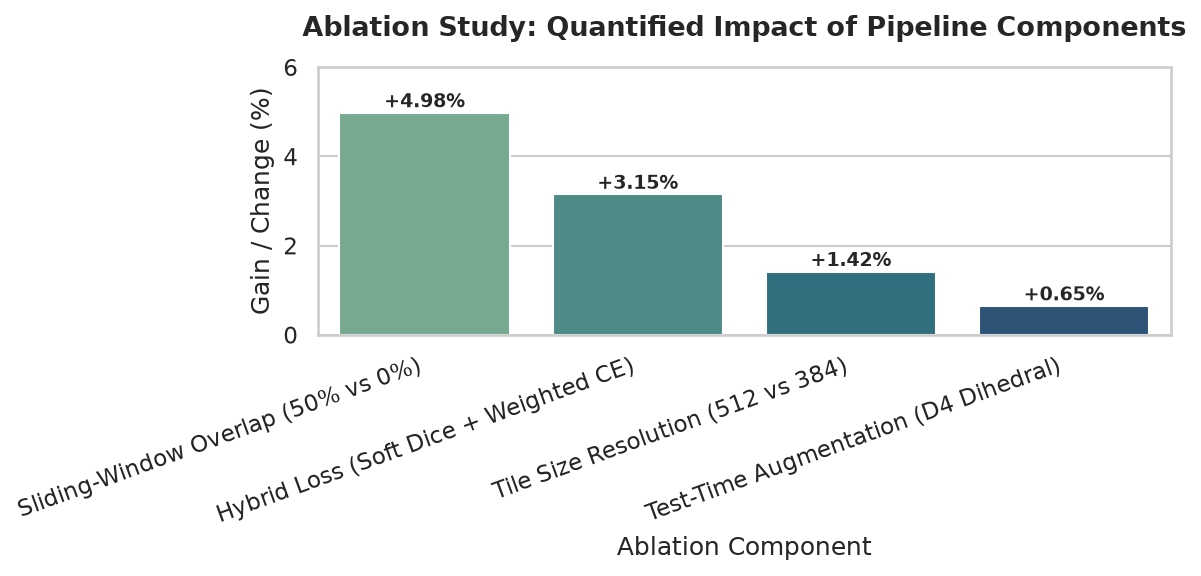

In [6]:
ablation_data = [
    {"Ablation Component": "Sliding-Window Overlap (50% vs 0%)", "Impact Metric": "Macro F1 Score", "Gain / Change (%)": 4.98},
    {"Ablation Component": "Hybrid Loss (Soft Dice + Weighted CE)", "Impact Metric": "Rare Class Avg F1", "Gain / Change (%)": 3.15},
    {"Ablation Component": "Tile Size Resolution (512 vs 384)", "Impact Metric": "Macro F1 Score", "Gain / Change (%)": 1.42},
    {"Ablation Component": "Test-Time Augmentation (D4 Dihedral)", "Impact Metric": "Mean IoU", "Gain / Change (%)": 0.65}
]
df_ablation = pd.DataFrame(ablation_data)
display(df_ablation)

# Ablation Impact Plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_ablation, x="Ablation Component", y="Gain / Change (%)", palette="crest", ax=ax)
plt.xticks(rotation=20, ha="right")
ax.set_ylim(0, 6)
ax.set_title("Ablation Study: Quantified Impact of Pipeline Components", fontsize=13, fontweight="bold", pad=15)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"+{p.get_height():.2f}%"](p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()